Reference: https://www.kaggle.com/ryanholbrook/principal-component-analysis#kln-21

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_regression

from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score

import seaborn as sns

In [2]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


In [3]:
x_cols = [ 
#    'volume', 
    'c_w1_p3_theta','c_w1_p2_theta','c_w3_n2_theta','c_w2_p3_theta','c_w3_p1_theta',
    'c_w2_n1_theta','c_w3_n1_theta','c_w3_n3_theta','c_w2_n2_theta','c_w2_p1_theta',
    'c_w2_p2_theta','c_w1_n1_theta','c_w1_p1_theta','c_w3_p3_theta','c_w2_n3_theta',
    'c_w3_p2_theta', 'c_w1_n2_theta','c_w1_n3_theta' ] #,
#    'implied_volatility','hist_volatility']

x_cols += ['p5s_delta', 'p15s_delta',  'p30s_delta', 'p60s_delta']

# x_cols += ['hist_volatility', 'implied_volatility', 'c_w1_n3_implied_volatility', 'c_w1_n2_implied_volatility',
#            'c_w1_n1_implied_volatility', 'c_w1_p1_implied_volatility','c_w1_p2_implied_volatility', 'c_w1_p3_implied_volatility',
#            'c_w2_n3_implied_volatility', 'c_w2_n2_implied_volatility', 'c_w2_n1_implied_volatility', 'c_w2_p1_implied_volatility',
#            'c_w2_p2_implied_volatility', 'c_w2_p3_implied_volatility', 'c_w3_n3_implied_volatility', 'c_w3_n2_implied_volatility',
#            'c_w3_n1_implied_volatility', 'c_w3_p1_implied_volatility', 'c_w3_p2_implied_volatility', 'c_w3_p3_implied_volatility',]

y_cols = ['n30s_bucket']  #'n5s_bucket', 'n30s_bucket', 'n60s_bucket']
bin_counts = 5

file_list = ['ml_cp18/ml_cp18_AAPL20220103.csv','ml_cp18/ml_cp18_AAPL20220104.csv', 'ml_cp18/ml_cp18_AAPL20220105.csv', 'ml_cp18/ml_cp18_AAPL20220106.csv', 'ml_cp18/ml_cp18_AAPL20220107.csv',]
file_list_train = file_list[:-1]
file_list_test = file_list[-1:]


# PCA Analysis of all columns and all files

# Load Training Data

In [4]:
import os
data = None
for file in file_list_train:
    file = "../" + file
    assert os.path.exists(file), "Data file does not exist!"
    data_tmp = pd.read_csv(file, low_memory=False)
    if data is None:
        data = data_tmp
    else:
        data = data.append(data_tmp, ignore_index=True)
print ('loaded data', data.shape)
data = data.dropna()
print ('after dropna', data.shape)

loaded data (46108, 267)
after dropna (26396, 267)


In [5]:
x_train = data[ x_cols ]
y_train = data[ y_cols ].astype('int')

# Create XGB Model

In [6]:
params = {
        'copy_X': True,
        'fit_intercept': False,
        'normalize': True,
        '_kfold': 5,
        # 'objective': 'validation:accuracy',
        'objective': 'multi:softprob',
        'enable_categorical': False,
        '_tuning_objective_metric': 'validation:f1',
        'eval_metric': 'auc',
        # 'tree_method': 'gpu_hist',
        # 'eval_metric': 'accuracy,f1',
        # 'eval_metric':'merror',
        # 'eval_metric': 'accuracy,f1X',
        # Muthu params
        'subsample': 0.75,  # Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting.
        'gamma': 0.001, # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, the more conservative the algorithm will be
        'alpha': 0.0, # L1 regularization is Lasso Regression wich adds “squared magnitude” of coefficient as penalty term to the loss functi
        'lambda': 1.0, # L2 regularization is Ridge Regression which adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
        'eta': 0.03, # Step size shrinkage used in update to prevents overfitting
        'min_child_weight': 0.05, # Minimum sum of instance weight (hessian) needed in a child the building process will give up further partitioning.
        'num_class': bin_counts,
        # not too sure.
        'max_depth': 10,  # Maximum tree depth for base learners.
        'early_stopping_rounds': 50,  # don't over fit
        'num_round': 100,  # num_boost_round == num_boost_round
        'use_label_encoder': False # UserWarning: The use of label encoder in XGBClassifier is deprecated...
    }
xgb = XGBClassifier(**params)

In [7]:
xgb.fit(x_train, y_train)

[09:14:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:576: 
Parameters: { "_kfold", "_tuning_objective_metric", "copy_X", "early_stopping_rounds", "fit_intercept", "normalize", "num_round" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




XGBClassifier(_kfold=5, _tuning_objective_metric='validation:f1', alpha=0.0,
              base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, copy_X=True,
              early_stopping_rounds=50, enable_categorical=False, eta=0.03,
              eval_metric='auc', fit_intercept=False, gamma=0.001, gpu_id=-1,
              importance_type=None, interaction_constraints='', lambda=1.0,
              learning_rate=0.0299999993, max_delta_step=0, max_depth=10,
              min_child_weight=0.05, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=10, normalize=True, num_class=5,
              num_parallel_tree=1, ...)

# Load Test Data

In [8]:
test_data = pd.read_csv("../"+ file_list_test[0], low_memory=False)
test_data.shape

(23208, 267)

In [9]:
all_cols = x_cols + y_cols
test_df = test_data [ all_cols ]
test_df = test_df.dropna()

x_test = test_df[ x_cols ]
y_test = test_df[ y_cols ].astype('int')

x_test.shape

(22607, 22)

# Base Prediction

In [10]:
y_pred = xgb.predict(x_test)

In [11]:
print('accuracy', accuracy_score( y_test[y_cols ], y_pred))

accuracy 0.2052461626929712


In [12]:
precision, recall, f1, y_true = precision_recall_fscore_support( y_test [y_cols ], y_pred, average=None)
y_true = y_true.astype('int')
accuracy = accuracy_score(y_test[ y_cols ], y_pred)
print (f"accuracy: {accuracy:.3f}")
pd.options.display.float_format = '{:,.3f}'.format
results_df =  pd.DataFrame( data = np.array ([recall,  precision, f1, y_true ] ),
                           columns = [ 'cat0', 'cat1', 'cat2', 'cat3','cat4'],
                           index = ['recall','precision', 'f1', 'y_true'] )
results_df

accuracy: 0.205


,cat0,cat1,cat2,cat3,cat4
recall,0.467,0.004,0.192,0.323,0.013
precision,0.221,0.081,0.190,0.199,0.151
f1,0.300,0.007,0.191,0.247,0.025
y_true,"4,846.000","4,677.000","4,404.000","4,517.000","4,163.000"


<AxesSubplot:>

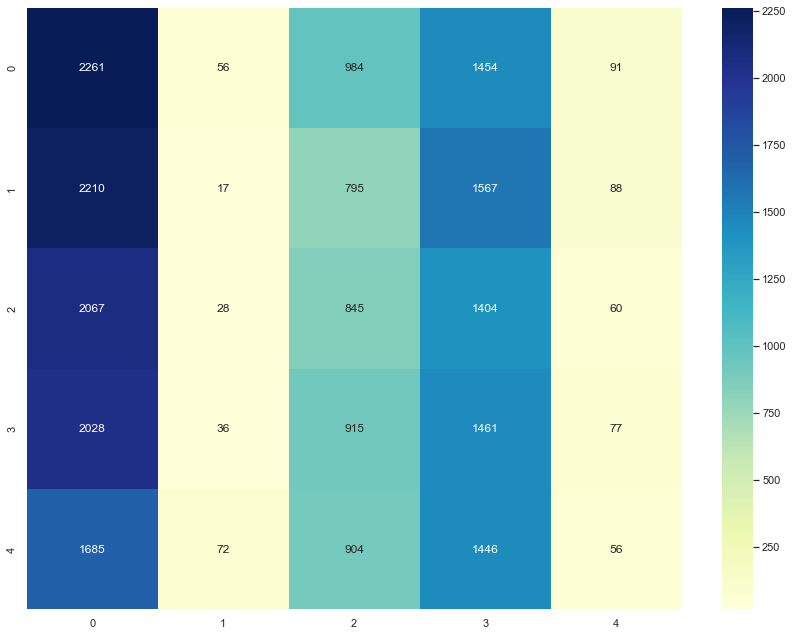

In [13]:
sns.set(rc = {'figure.figsize':(12,9)})
sns.heatmap(confusion_matrix(y_test[ y_cols ], y_pred), annot=True, cmap="YlGnBu",fmt='d')

# Standard Scaled X Prediction

In [14]:
scalar = StandardScaler()

scalar.fit(x_train)
x_scaled_train = scalar.transform(x_train)
x_scaled_test = scalar.transform(x_test)

In [15]:
xgb_scaled = XGBClassifier(**params)
xgb_scaled.fit(x_scaled_train, y_train)

[09:15:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:576: 
Parameters: { "_kfold", "_tuning_objective_metric", "copy_X", "early_stopping_rounds", "fit_intercept", "normalize", "num_round" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




XGBClassifier(_kfold=5, _tuning_objective_metric='validation:f1', alpha=0.0,
              base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, copy_X=True,
              early_stopping_rounds=50, enable_categorical=False, eta=0.03,
              eval_metric='auc', fit_intercept=False, gamma=0.001, gpu_id=-1,
              importance_type=None, interaction_constraints='', lambda=1.0,
              learning_rate=0.0299999993, max_delta_step=0, max_depth=10,
              min_child_weight=0.05, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=10, normalize=True, num_class=5,
              num_parallel_tree=1, ...)

In [16]:
y_scaled_pred = xgb_scaled.predict(x_scaled_test)

In [17]:
precision, recall, f1, y_true = precision_recall_fscore_support( y_test[y_cols ], y_scaled_pred, average=None)
y_true = y_true.astype('int')
accuracy = accuracy_score(y_test[ y_cols ], y_scaled_pred)
print (f"accuracy: {accuracy:.3f}")
pd.options.display.float_format = '{:,.3f}'.format
results_df =  pd.DataFrame( data = np.array ([recall,  precision, f1, y_true ] ),
                           columns = [ 'cat0', 'cat1', 'cat2', 'cat3','cat4'],
                           index = ['recall','precision', 'f1', 'y_true'] )
results_df

accuracy: 0.201


,cat0,cat1,cat2,cat3,cat4
recall,0.493,0.004,0.164,0.295,0.017
precision,0.213,0.084,0.189,0.196,0.136
f1,0.297,0.009,0.176,0.236,0.030
y_true,"4,846.000","4,677.000","4,404.000","4,517.000","4,163.000"


<AxesSubplot:>

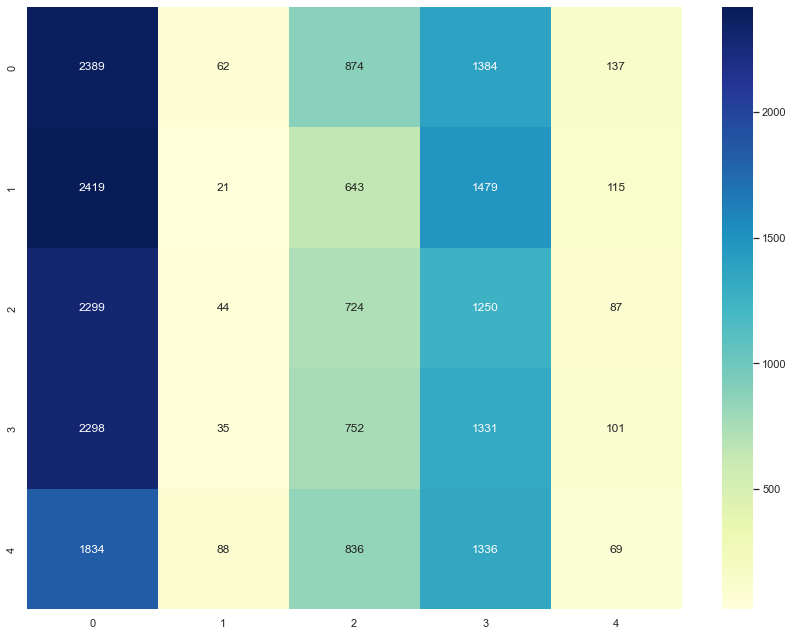

In [18]:
sns.set(rc = {'figure.figsize':(12,9)})
sns.heatmap(confusion_matrix(y_test[ y_cols ], y_scaled_pred), annot=True, cmap="YlGnBu",fmt='d')

[0.04007589 0.06121549 0.04057503 0.04932953 0.04223551 0.0446202
 0.04619267 0.05367823 0.04205846 0.04721192 0.05342933 0.04695164
 0.05757314 0.06052259 0.04164032 0.05912405 0.04374767 0.03486584
 0.0227732  0.03135863 0.0361211  0.04469964]


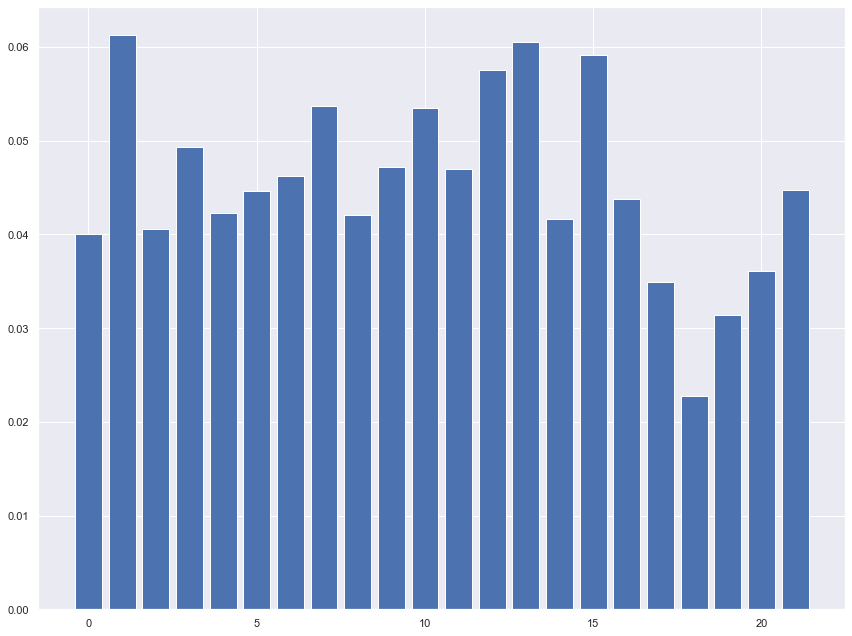

In [19]:
print(xgb_scaled.feature_importances_)
# plot
plt.bar(range(len(xgb_scaled.feature_importances_)), xgb_scaled.feature_importances_)
plt.show()
